# Cross-City Crime Pattern Analysis & Transfer Learning
## Full Experimental Pipeline (Temporal Split Version)

**Key design decisions:**
- Grid-level dominant category prediction (not event-level)
- Temporal split: Train (past) / Val / Test (future) — same grid appears in all splits at different times
- hist_* features computed from TRAIN period only, predicting TEST period dominant category
- No spatial leakage, no feature-target leakage

**Layers:**
1. Baseline: CatBoost + LightGBM
2. Precision optimization: calibration, confidence threshold, class-specific threshold, two-stage
3. Transfer learning: zero-shot, fine-tuning, teacher-student
4. Map output

In [1]:
# ============================================================
# CELL 0: Setup
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib
warnings.filterwarnings('ignore')

PROC_DIR  = '../data/processed'
MODEL_DIR = '../outputs/models'
EDA_DIR   = '../outputs/eda'
for d in [MODEL_DIR, EDA_DIR]:
    os.makedirs(d, exist_ok=True)

# origin: CATEGORIES  = ['violent', 'property', 'drug', 'public_order', 'other']
CATEGORIES = ['violent', 'property', 'other']
CITY_COLORS = {'NYC': '#378ADD', 'Chicago': '#1D9E75', 'Karachi': '#D85A30'}
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

def safe_report(y_true, y_pred, le, zero_division=0):
    """classification_report showing only classes present in predictions."""
    present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    present_names  = [le.classes_[i] for i in present_labels]
    return classification_report(
        y_true, y_pred,
        labels=present_labels,
        target_names=present_names,
        zero_division=zero_division
    )

def safe_confusion_matrix(y_true, y_pred, le, ax, title, cmap='Blues'):
    """Plot confusion matrix with only classes present in predictions."""
    present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    present_names  = [le.classes_[i] for i in present_labels]
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=present_labels),
        display_labels=present_names
    ).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)

print('Setup complete')

Setup complete


In [2]:
MERGE_MAP = {'drug': 'other', 'public_order': 'public_order'}  # keep public_order for now

## Section 1 — Load Data

In [3]:
# ============================================================
# CELL 1: Load data
# ============================================================
df = pd.read_csv(f'{PROC_DIR}/all_cities.csv', low_memory=False)
df = df.dropna(subset=['latitude', 'longitude', 'crime_category'])
df = df[df['crime_category'].isin(CATEGORIES)]
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])
print(f'Total records: {len(df):,}')
print(df['city'].value_counts().to_string())
print(f'\nDate range: {df["datetime"].min()} to {df["datetime"].max()}')

Total records: 15,797,173
city
NYC        8394926
Chicago    6531182
LA          861147
Karachi       9918

Date range: 2001-01-01 00:00:00 to 2024-12-31 23:58:00


## Section 2 — Grid Dataset & Temporal Split

In [4]:
# Cell 2
def build_grid_from_events(events, grid_size=0.01, min_count=3):
    d = events.copy()
    d['lat_bin']   = (d['latitude']  / grid_size).round() * grid_size
    d['lon_bin']   = (d['longitude'] / grid_size).round() * grid_size
    d['time_slot'] = pd.cut(d['hour'], bins=[-1,5,11,17,23],
                            labels=[0,1,2,3]).astype(int)

    # Merge rare category before counting
    d['crime_category'] = d['crime_category'].replace({
        'drug': 'other',
        'public_order': 'other'
    })
    for cat in CATEGORIES:
        d[f'cnt_{cat}'] = (d['crime_category'] == cat).astype(int)

    agg = {
        'total_count':  ('crime_category', 'size'),
        'hour_mean':    ('hour',    'mean'),
        'month_mean':   ('month',   'mean'),
        'weekday_mean': ('weekday', 'mean'),
    }
    for cat in CATEGORIES:
        agg[f'cnt_{cat}'] = (f'cnt_{cat}', 'sum')

    grid = d.groupby(['lat_bin','lon_bin','time_slot']).agg(**agg).reset_index()
    cnt_cols = [f'cnt_{cat}' for cat in CATEGORIES]

    for cat in CATEGORIES:
        grid[f'hist_{cat}'] = grid[f'cnt_{cat}'] / grid['total_count']

    grid['dominant_category'] = (
        grid[cnt_cols].idxmax(axis=1).str.replace('cnt_', '', regex=False)
    )
    counts_arr  = grid[cnt_cols].values
    grid['top1_ratio']    = counts_arr.max(axis=1) / grid['total_count']
    sorted_c              = np.sort(counts_arr, axis=1)[:,::-1]
    grid['dominance_gap'] = (sorted_c[:,0] - sorted_c[:,1]) / grid['total_count']
    hist_arr              = np.clip(counts_arr / grid['total_count'].values.reshape(-1,1), 1e-9, 1)
    grid['entropy']       = scipy_entropy(hist_arr.T)
    grid['log_count']     = np.log1p(grid['total_count'])

    grid = grid[grid['total_count'] >= min_count].copy()
    return grid

In [5]:
# ============================================================
# CELL 3: Temporal split (auto-adapts to each city's date range)
# ============================================================

# ---- Select city ----
CITY = 'LA'   # change to: 'NYC', 'Chicago', 'LA', 'Karachi'
# ---------------------

city_events = df[df['city'] == CITY].copy()
max_date    = city_events['datetime'].max()
min_date    = city_events['datetime'].min()
total_days  = (max_date - min_date).days

print(f'City: {CITY}')
print(f'Date range: {min_date.date()} to {max_date.date()} ({total_days} days)')
print(f'Total records: {len(city_events):,}')

# Dynamic split: test=last 20%, val=preceding 20%, train=first 60%
test_start = max_date - pd.Timedelta(days=int(total_days * 0.20))
val_start  = max_date - pd.Timedelta(days=int(total_days * 0.40))

train_events = city_events[city_events['datetime'] <  val_start]
val_events   = city_events[(city_events['datetime'] >= val_start) &
                            (city_events['datetime'] <  test_start)]
test_events  = city_events[city_events['datetime'] >= test_start]

print(f'\nTemporal split (60/20/20 by time):')
print(f'  Train: {len(train_events):,} records  (up to {val_start.date()})')
print(f'  Val:   {len(val_events):,} records  ({val_start.date()} – {test_start.date()})')
print(f'  Test:  {len(test_events):,} records  ({test_start.date()} onwards)')

print('\nBuilding grid datasets...')
grid_train = build_grid_from_events(train_events)
grid_val   = build_grid_from_events(val_events)
grid_test  = build_grid_from_events(test_events)

print(f'\nTrain grids: {len(grid_train):,}')
print(f'Val   grids: {len(grid_val):,}')
print(f'Test  grids: {len(grid_test):,}')

train_locs = set(zip(grid_train['lat_bin'].round(4), grid_train['lon_bin'].round(4)))
test_locs  = set(zip(grid_test['lat_bin'].round(4),  grid_test['lon_bin'].round(4)))
overlap    = train_locs & test_locs
print(f'\nCoordinate overlap: {len(overlap):,}/{len(test_locs):,} ({len(overlap)/max(len(test_locs),1):.1%})')

City: LA
Date range: 2020-01-01 to 2023-12-31 (1460 days)
Total records: 861,147

Temporal split (60/20/20 by time):
  Train: 493,456 records  (up to 2022-05-26)
  Val:   186,904 records  (2022-05-26 – 2023-03-14)
  Test:  180,787 records  (2023-03-14 onwards)

Building grid datasets...

Train grids: 4,635
Val   grids: 4,173
Test  grids: 4,130

Coordinate overlap: 1,132/1,136 (99.6%)


## Section 3 — Feature Engineering

In [6]:
# ============================================================
# CELL 4: Spatial lag + feature matrix
# ============================================================
def add_spatial_lag(grid):
    """Spatial autocorrelation: neighboring grids' crime composition."""
    step = 0.01
    for cat in CATEGORIES:
        lags = []
        for _, row in grid.iterrows():
            lat, lon = row['lat_bin'], row['lon_bin']
            mask = (
                grid['lat_bin'].between(lat-step*1.5, lat+step*1.5) &
                grid['lon_bin'].between(lon-step*1.5, lon+step*1.5) &
                ~((grid['lat_bin']==lat) & (grid['lon_bin']==lon))
            )
            nb = grid[mask]
            lags.append(nb[f'hist_{cat}'].mean() if len(nb)>0 else row[f'hist_{cat}'])
        grid[f'lag_{cat}'] = lags
    return grid

# Cell 4: 把 FEATURE_COLS 這段改成動態生成
FEATURE_COLS = [
    'lat_bin','lon_bin','lat_norm','lon_norm',
    'density_pct','violent_pct','entropy_pct','dom_gap_pct',
    'time_slot','is_weekend','log_count',
    'hour_sin','hour_cos','month_sin','month_cos','weekday_sin','weekday_cos',
    'top1_ratio','dominance_gap','entropy',
] + [f'hist_{c}' for c in CATEGORIES] \
  + [f'lag_{c}'  for c in CATEGORIES]

print(f'Feature columns ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)
CAT_COLS = ['time_slot','is_weekend']

def make_features(grid_period, ref_grid=None):
    """
    Build feature matrix.
    grid_period: the grid whose TARGET we predict (val or test)
    ref_grid:    the grid providing hist_* features (always train)
                 If None, use grid_period's own hist_* (for train set)
    """
    d = grid_period.copy()

    if ref_grid is not None:
        # Use TRAIN hist_* as features for val/test
        # (past behaviour -> predict future dominant category)
        hist_cols = ['lat_bin','lon_bin','time_slot'] + \
                    [f'hist_{c}' for c in CATEGORIES] + \
                    [f'lag_{c}'  for c in CATEGORIES] + \
                    ['log_count','top1_ratio','dominance_gap','entropy']
        available = [c for c in hist_cols if c in ref_grid.columns]
        ref = ref_grid[available].copy()
        # Drop hist_* columns from d before merging ref
        drop_cols = [c for c in available if c not in ['lat_bin','lon_bin','time_slot']]
        d = d.drop(columns=[c for c in drop_cols if c in d.columns])
        d = d.merge(ref, on=['lat_bin','lon_bin','time_slot'], how='left')
        # Fallback: grids not seen in train -> use median from train
        for c in CATEGORIES:
            med = ref_grid[f'hist_{c}'].median()
            d[f'hist_{c}'] = d[f'hist_{c}'].fillna(med)
            if f'lag_{c}' in d.columns:
                d[f'lag_{c}'] = d[f'lag_{c}'].fillna(med)
            else:
                d[f'lag_{c}'] = med
        d['log_count']     = d['log_count'].fillna(ref_grid['log_count'].median())
        d['top1_ratio']    = d['top1_ratio'].fillna(ref_grid['top1_ratio'].median())
        d['dominance_gap'] = d['dominance_gap'].fillna(ref_grid['dominance_gap'].median())
        d['entropy']       = d['entropy'].fillna(ref_grid['entropy'].median())

    # Temporal encoding
    d['hour_sin']    = np.sin(2*np.pi*d['hour_mean']   /24)
    d['hour_cos']    = np.cos(2*np.pi*d['hour_mean']   /24)
    d['month_sin']   = np.sin(2*np.pi*d['month_mean']  /12)
    d['month_cos']   = np.cos(2*np.pi*d['month_mean']  /12)
    d['weekday_sin'] = np.sin(2*np.pi*d['weekday_mean']/7)
    d['weekday_cos'] = np.cos(2*np.pi*d['weekday_mean']/7)
    d['is_weekend']  = (d['weekday_mean'] >= 5).astype(int)

    # Spatial
    d['lat_norm'] = (d['lat_bin']-d['lat_bin'].mean())/(d['lat_bin'].std()+1e-8)
    d['lon_norm'] = (d['lon_bin']-d['lon_bin'].mean())/(d['lon_bin'].std()+1e-8)

    # Relative percentile (rank within this period)
    d['density_pct'] = d['log_count'].rank(pct=True)
    d['violent_pct'] = d['hist_violent'].rank(pct=True)
    d['entropy_pct'] = d['entropy'].rank(pct=True)
    d['dom_gap_pct'] = d['dominance_gap'].rank(pct=True)

    # Ensure lag columns exist
    for c in CATEGORIES:
        if f'lag_{c}' not in d.columns:
            d[f'lag_{c}'] = d[f'hist_{c}']

    return d[FEATURE_COLS].fillna(0)


def prep_cat(Xdf):
    Xc = Xdf.copy()
    for c in CAT_COLS:
        if c in Xc.columns:
            Xc[c] = Xc[c].astype(str)
    return Xc

print('Feature functions defined')

Feature columns (26):
['lat_bin', 'lon_bin', 'lat_norm', 'lon_norm', 'density_pct', 'violent_pct', 'entropy_pct', 'dom_gap_pct', 'time_slot', 'is_weekend', 'log_count', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'top1_ratio', 'dominance_gap', 'entropy', 'hist_violent', 'hist_property', 'hist_other', 'lag_violent', 'lag_property', 'lag_other']
Feature functions defined


In [7]:
# ============================================================
# CELL 5: Compute spatial lag (train only) + build feature matrices
# ============================================================
print('Computing spatial lag on train grid (takes a few minutes)...')
grid_train = add_spatial_lag(grid_train)
print('Done')

le = LabelEncoder()
# Re-fit based on actual categories present after merging drug->other
actual_cats = sorted(grid_train['dominant_category'].unique())
le.fit(actual_cats)
print(f'Classes after merge: {le.classes_}')

# Train: use its own hist_* (ref_grid=None)
# Val/Test: use train hist_* as features, predict val/test dominant category
X_train = make_features(grid_train, ref_grid=None)
X_val   = make_features(grid_val,   ref_grid=grid_train)
X_test  = make_features(grid_test,  ref_grid=grid_train)

y_train = le.transform(grid_train['dominant_category'])
y_val   = le.transform(grid_val['dominant_category'])
y_test  = le.transform(grid_test['dominant_category'])

cat_idx = [list(X_train.columns).index(c) for c in CAT_COLS if c in X_train.columns]

print(f'\nFeatures: {X_train.shape[1]}')
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'\nTest hist_* coverage from train: {(X_test["hist_violent"]!=X_val["hist_violent"].median()).mean():.1%}')
print(f'Classes: {le.classes_}')

Computing spatial lag on train grid (takes a few minutes)...
Done
Classes after merge: ['other' 'property' 'violent']

Features: 26
Train: 4,635  Val: 4,173  Test: 4,130

Test hist_* coverage from train: 99.8%
Classes: ['other' 'property' 'violent']


## Section 4 — Baseline Training

In [8]:
# ============================================================
# CELL 6: CatBoost baseline
# ============================================================
from catboost import CatBoostClassifier, Pool

model_cat = CatBoostClassifier(
    iterations=800, depth=8, learning_rate=0.03,
    loss_function='MultiClass', eval_metric='TotalF1',
    auto_class_weights='Balanced',
    cat_features=cat_idx, random_seed=42, verbose=100,
)
model_cat.fit(
    Pool(prep_cat(X_train), y_train, cat_features=cat_idx),
    eval_set=Pool(prep_cat(X_val), y_val, cat_features=cat_idx),
    early_stopping_rounds=80,
)
print('CatBoost training complete')

0:	learn: 0.9227388	test: 0.3848109	best: 0.3848109 (0)	total: 205ms	remaining: 2m 43s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.387970407
bestIteration = 1

Shrink model to first 2 iterations.
CatBoost training complete


In [9]:
# ============================================================
# CELL 7: LightGBM baseline
# ============================================================
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
    n_estimators=800, max_depth=8, learning_rate=0.03,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1,
)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(100)],
)
print('LightGBM training complete')

[100]	valid_0's multi_logloss: 1.43342
LightGBM training complete


## Section 5 — Test Set Evaluation


===== CatBoost [LA] TEST SET =====
Precision macro    = 0.4853
Precision weighted = 0.6256
Recall macro       = 0.4805
F1 macro           = 0.4828
              precision    recall  f1-score   support

       other       0.26      0.24      0.25       631
    property       0.75      0.77      0.76      2815
     violent       0.45      0.43      0.44       684

    accuracy                           0.63      4130
   macro avg       0.49      0.48      0.48      4130
weighted avg       0.63      0.63      0.63      4130



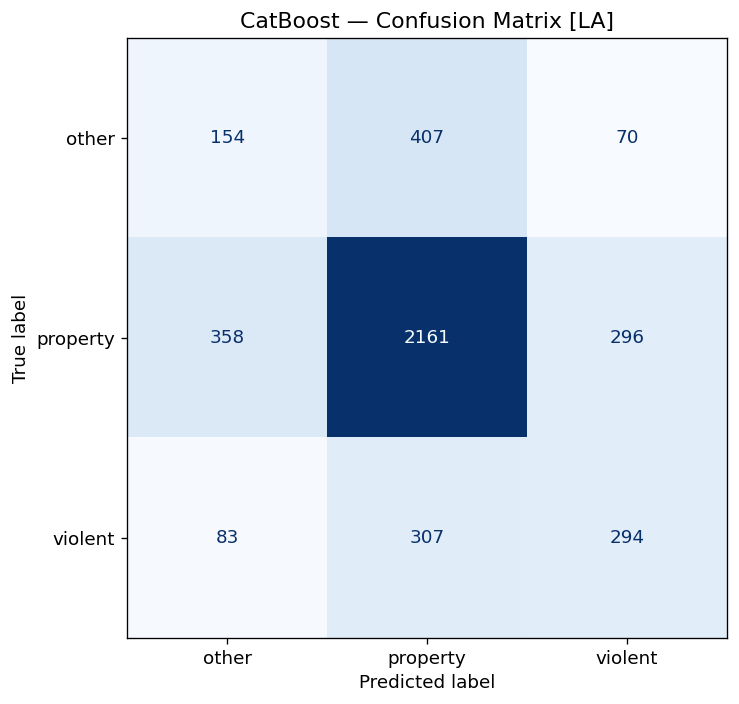


===== LightGBM [LA] TEST SET =====
Precision macro    = 0.4998
Precision weighted = 0.6204
Recall macro       = 0.4434
F1 macro           = 0.4560
              precision    recall  f1-score   support

       other       0.29      0.15      0.20       631
    property       0.73      0.87      0.79      2815
     violent       0.48      0.31      0.37       684

    accuracy                           0.67      4130
   macro avg       0.50      0.44      0.46      4130
weighted avg       0.62      0.67      0.63      4130



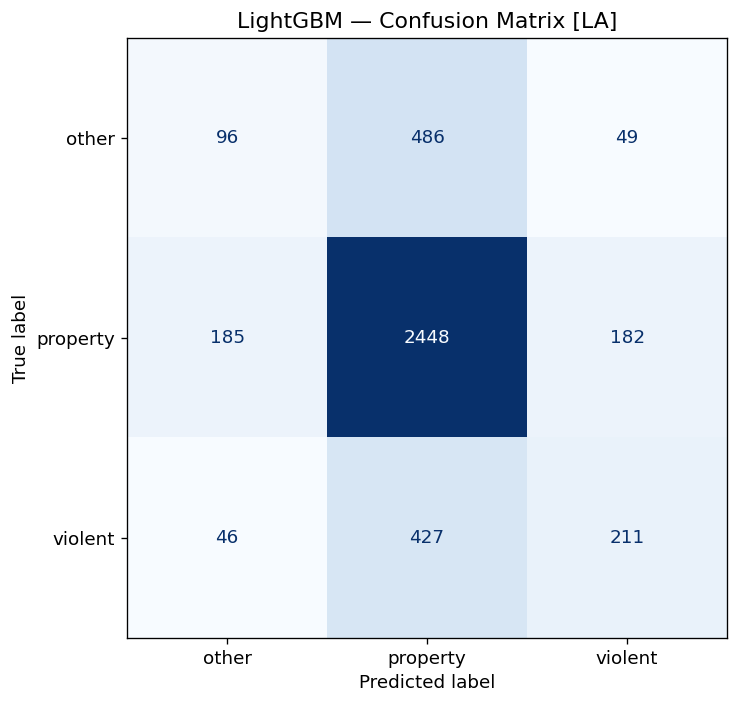

In [10]:
# ============================================================
# CELL 8: Full evaluation on test set
# ============================================================
def full_eval(model, X_test, y_test, le, name, use_cat=False):
    Xt     = prep_cat(X_test) if use_cat else X_test
    y_pred = model.predict(Xt)
    if hasattr(y_pred, 'flatten'):
        y_pred = y_pred.flatten()
    proba  = model.predict_proba(Xt)

    pm = precision_score(y_test, y_pred, average='macro',    zero_division=0)
    pw = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test,        y_pred, average='macro',    zero_division=0)
    rc = recall_score(y_test,    y_pred, average='macro',    zero_division=0)

    print(f'\n===== {name} [{CITY}] TEST SET =====')
    print(f'Precision macro    = {pm:.4f}')
    print(f'Precision weighted = {pw:.4f}')
    print(f'Recall macro       = {rc:.4f}')
    print(f'F1 macro           = {f1:.4f}')
    print(safe_report(y_test, y_pred, le))

    fig, ax = plt.subplots(figsize=(7,6))
    safe_confusion_matrix(y_test, y_pred, le, ax,
                          f'{name} — Confusion Matrix [{CITY}]')
    plt.tight_layout()
    plt.savefig(f'{EDA_DIR}/cm_{CITY.lower()}_{name.lower().replace(" ","_")}.png', dpi=150)
    plt.show()
    return y_pred, proba, pm, pw, f1

_, proba_cat, pm_cat, pw_cat, f1_cat = full_eval(model_cat, X_test, y_test, le, 'CatBoost', use_cat=True)
_, proba_lgb, pm_lgb, pw_lgb, f1_lgb = full_eval(model_lgb, X_test, y_test, le, 'LightGBM')

## Section 6 — Probability Calibration

In [11]:
# ============================================================
# CELL 9: Probability calibration (Platt + Isotonic)
# ============================================================
def calibrate_probabilities(raw_proba, y_val, method='platt'):
    calibrators = []
    for cls_idx in range(raw_proba.shape[1]):
        y_binary = (y_val == cls_idx).astype(int)
        p_cls    = raw_proba[:, cls_idx].reshape(-1, 1)
        if len(np.unique(y_binary)) < 2:
            calibrators.append(None)
            continue
        try:
            if method == 'platt':
                cal = LogisticRegression(C=1.0, max_iter=500)
                cal.fit(p_cls, y_binary)
            else:
                cal = IsotonicRegression(out_of_bounds='clip')
                cal.fit(p_cls.ravel(), y_binary)
            calibrators.append(cal)
        except Exception:
            calibrators.append(None)
    return calibrators

def apply_calibration(calibrators, raw_proba, method='platt'):
    cal_proba = np.zeros_like(raw_proba)
    for cls_idx, cal in enumerate(calibrators):
        p = raw_proba[:, cls_idx].reshape(-1, 1)
        if cal is None:
            cal_proba[:, cls_idx] = raw_proba[:, cls_idx]
        elif method == 'platt':
            cal_proba[:, cls_idx] = cal.predict_proba(p)[:, 1]
        else:
            cal_proba[:, cls_idx] = cal.predict(p.ravel())
    row_sums = cal_proba.sum(axis=1, keepdims=True)
    return cal_proba / np.clip(row_sums, 1e-9, None)

proba_cat_val = model_cat.predict_proba(prep_cat(X_val))
proba_lgb_val = model_lgb.predict_proba(X_val)

cal_platt_cat = calibrate_probabilities(proba_cat_val, y_val, 'platt')
cal_iso_cat   = calibrate_probabilities(proba_cat_val, y_val, 'isotonic')
cal_platt_lgb = calibrate_probabilities(proba_lgb_val, y_val, 'platt')
cal_iso_lgb   = calibrate_probabilities(proba_lgb_val, y_val, 'isotonic')

proba_cat_platt = apply_calibration(cal_platt_cat, proba_cat,  'platt')
proba_cat_iso   = apply_calibration(cal_iso_cat,   proba_cat,  'isotonic')
proba_lgb_platt = apply_calibration(cal_platt_lgb, proba_lgb,  'platt')
proba_lgb_iso   = apply_calibration(cal_iso_lgb,   proba_lgb,  'isotonic')

print('Calibration complete')
print(f'CatBoost raw   max_proba mean: {proba_cat.max(axis=1).mean():.4f}')
print(f'CatBoost Platt max_proba mean: {proba_cat_platt.max(axis=1).mean():.4f}')
print(f'CatBoost Iso   max_proba mean: {proba_cat_iso.max(axis=1).mean():.4f}')

Calibration complete
CatBoost raw   max_proba mean: 0.3634
CatBoost Platt max_proba mean: 0.7475
CatBoost Iso   max_proba mean: 0.7473


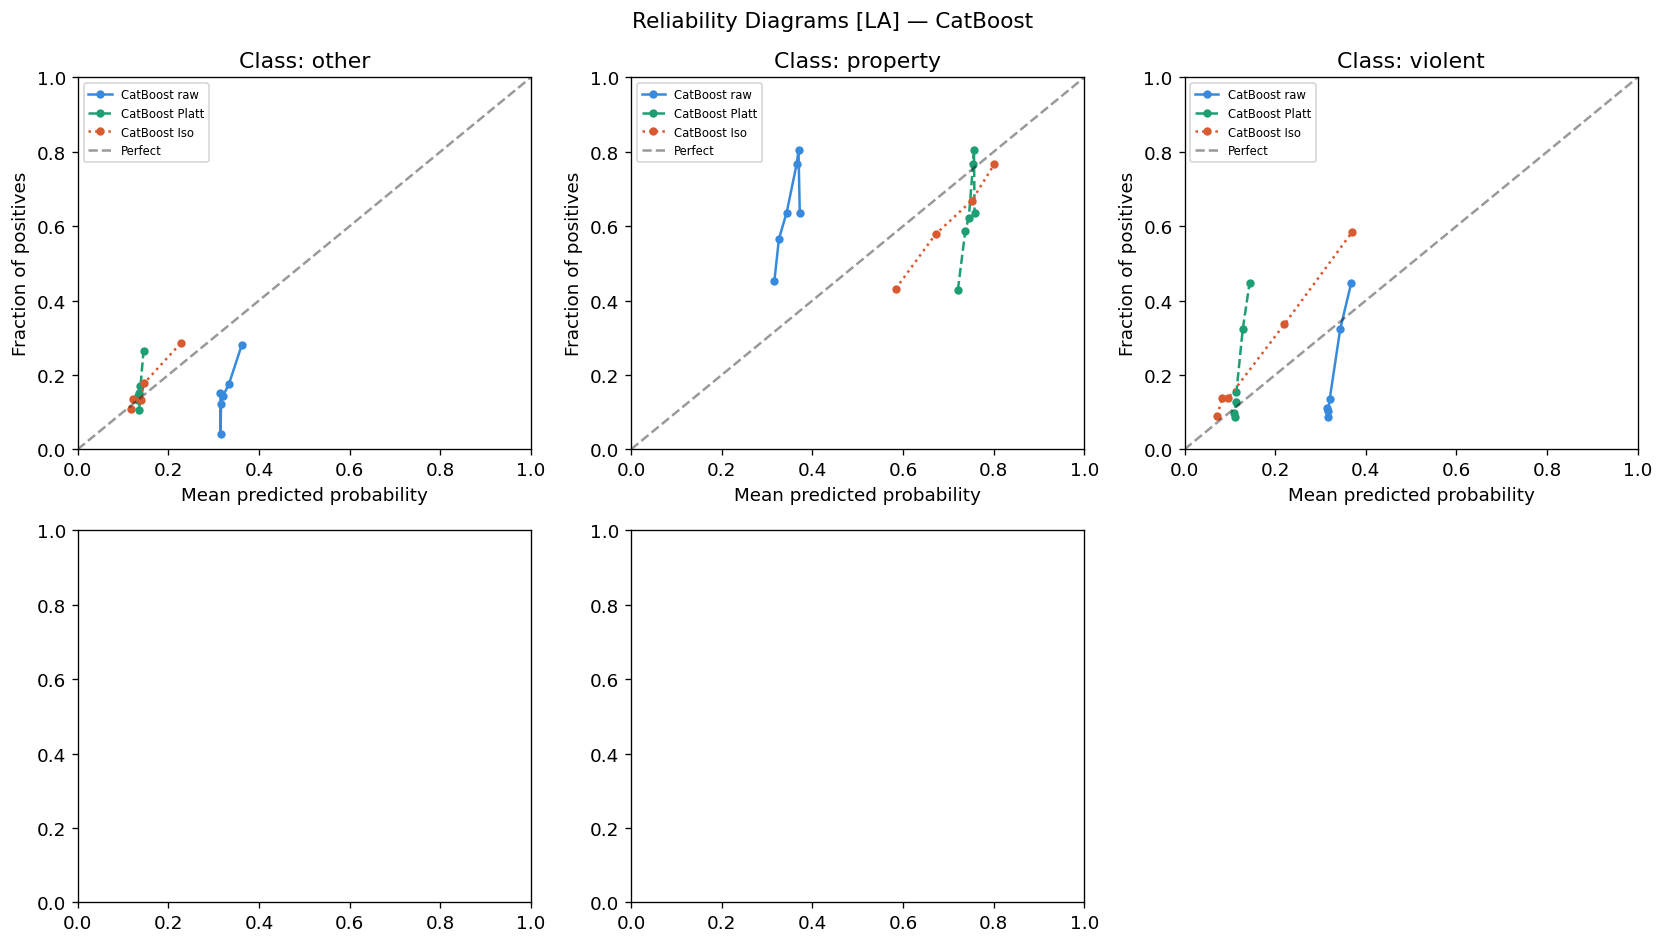

Saved ../outputs/eda/reliability_la_CatBoost.png


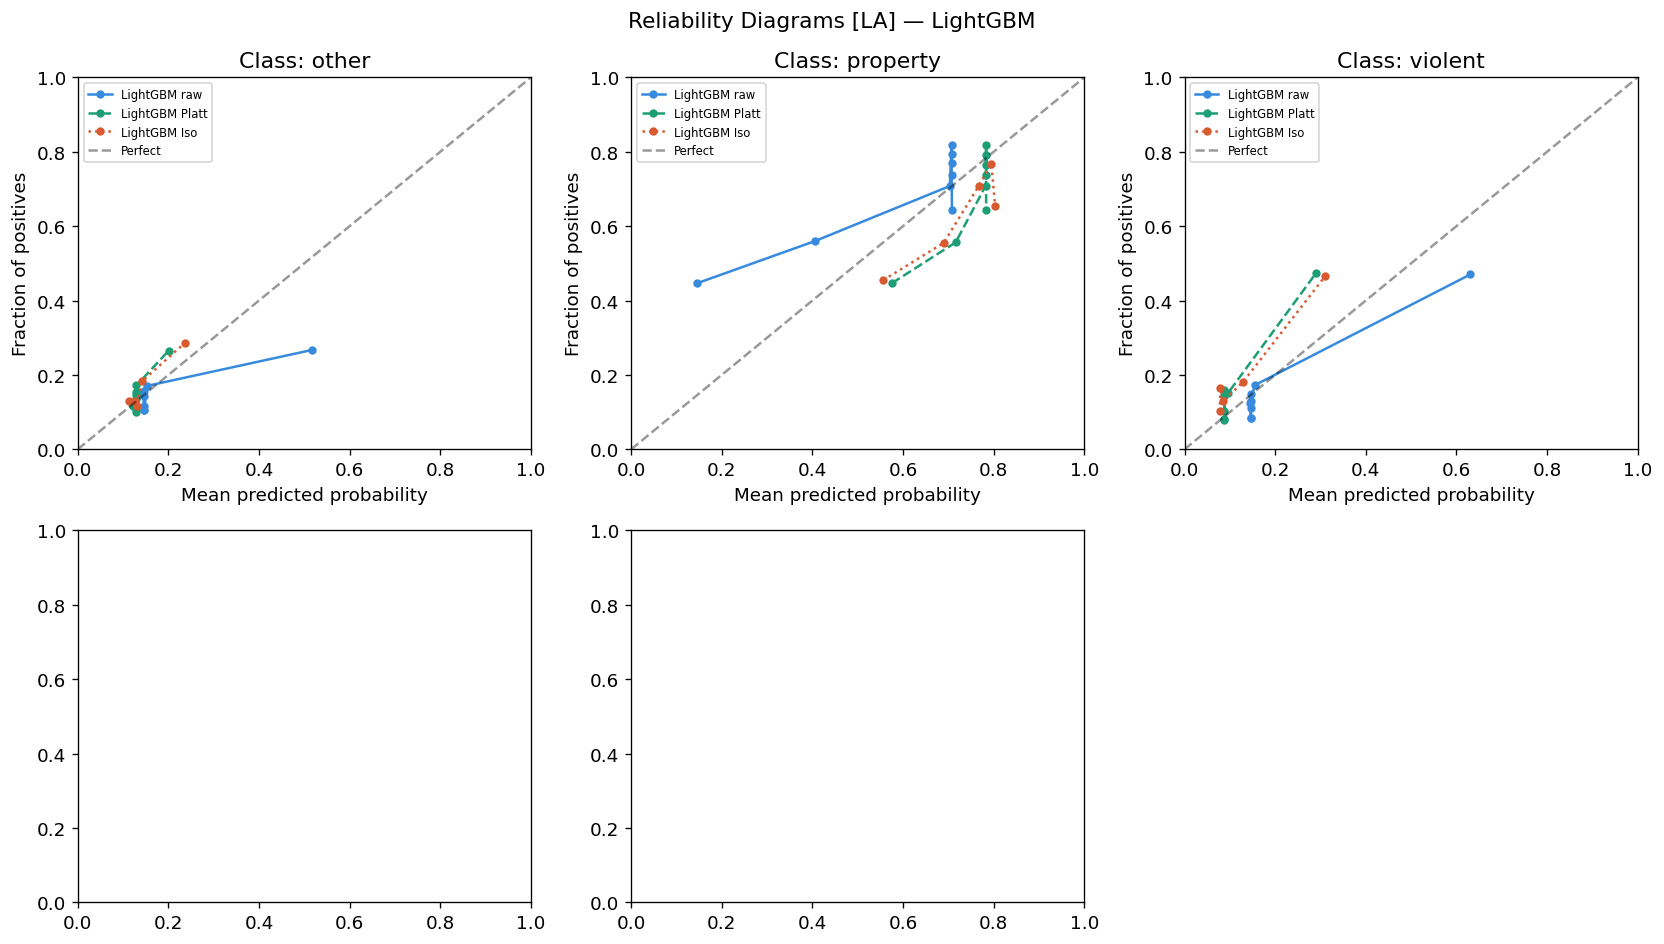

Saved ../outputs/eda/reliability_la_LightGBM.png


In [12]:
# ============================================================
# CELL 10: Reliability diagrams
# ============================================================
def plot_reliability(proba_dict, y_test, le, title_suffix):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    for cls_idx, cls_name in enumerate(le.classes_):
        ax = axes[cls_idx]
        y_bin = (y_test == cls_idx).astype(int)
        if y_bin.sum() == 0:
            ax.set_title(f'{cls_name} (no samples)')
            continue
        for label, proba, color, ls in proba_dict:
            try:
                frac, mean_p = calibration_curve(y_bin, proba[:,cls_idx], n_bins=8, strategy='quantile')
                ax.plot(mean_p, frac, marker='o', label=label, color=color, ls=ls, lw=1.5, ms=4)
            except Exception:
                pass
        ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Perfect')
        ax.set_title(f'Class: {cls_name}')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.legend(fontsize=7)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
    axes[-1].set_visible(False)
    fig.suptitle(f'Reliability Diagrams [{CITY}] — {title_suffix}', fontsize=13)
    plt.tight_layout()
    fname = f'{EDA_DIR}/reliability_{CITY.lower()}_{title_suffix.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved {fname}')

plot_reliability([
    ('CatBoost raw',   proba_cat,       '#378ADD', '-'),
    ('CatBoost Platt', proba_cat_platt, '#1D9E75', '--'),
    ('CatBoost Iso',   proba_cat_iso,   '#D85A30', ':'),
], y_test, le, 'CatBoost')

plot_reliability([
    ('LightGBM raw',   proba_lgb,       '#378ADD', '-'),
    ('LightGBM Platt', proba_lgb_platt, '#1D9E75', '--'),
    ('LightGBM Iso',   proba_lgb_iso,   '#D85A30', ':'),
], y_test, le, 'LightGBM')

## Section 7 — Confidence Threshold & Selective Prediction

In [13]:
# ============================================================
# CELL 11: Global confidence threshold sweep
# ============================================================
def selective_precision_sweep(proba_dict, y_test, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.30, 0.96, 0.05)
    results = {}
    for label, proba in proba_dict:
        rows = []
        for t in thresholds:
            confident = proba.max(axis=1) >= t
            if confident.sum() < 10:
                rows.append({'threshold': round(t,2), 'coverage': 0.0,
                             'n_predicted': 0, 'precision_macro': np.nan,
                             'precision_weighted': np.nan, 'f1_macro': np.nan})
                continue
            yc = y_test[confident]
            pc = proba.argmax(axis=1)[confident]
            pm = precision_score(yc, pc, average='macro',    zero_division=0)
            pw = precision_score(yc, pc, average='weighted', zero_division=0)
            f1 = f1_score(yc,     pc, average='macro',    zero_division=0)
            rows.append({'threshold': round(t,2),
                         'coverage': round(confident.mean(),3),
                         'n_predicted': int(confident.sum()),
                         'precision_macro': round(pm,4),
                         'precision_weighted': round(pw,4),
                         'f1_macro': round(f1,4)})
        results[label] = pd.DataFrame(rows)
        print(f'\n--- {label} ---')
        print(results[label].to_string(index=False))
    return results

sweep_results = selective_precision_sweep([
    ('CatBoost raw',   proba_cat),
    ('CatBoost Platt', proba_cat_platt),
    ('CatBoost Iso',   proba_cat_iso),
    ('LightGBM raw',   proba_lgb),
    ('LightGBM Platt', proba_lgb_platt),
], y_test)


--- CatBoost raw ---
 threshold  coverage  n_predicted  precision_macro  precision_weighted  f1_macro
      0.30     1.000         4130           0.4853              0.6256    0.4828
      0.35     0.846         3493           0.5002              0.6420    0.4873
      0.40     0.000            0              NaN                 NaN       NaN
      0.45     0.000            0              NaN                 NaN       NaN
      0.50     0.000            0              NaN                 NaN       NaN
      0.55     0.000            0              NaN                 NaN       NaN
      0.60     0.000            0              NaN                 NaN       NaN
      0.65     0.000            0              NaN                 NaN       NaN
      0.70     0.000            0              NaN                 NaN       NaN
      0.75     0.000            0              NaN                 NaN       NaN
      0.80     0.000            0              NaN                 NaN       NaN
      

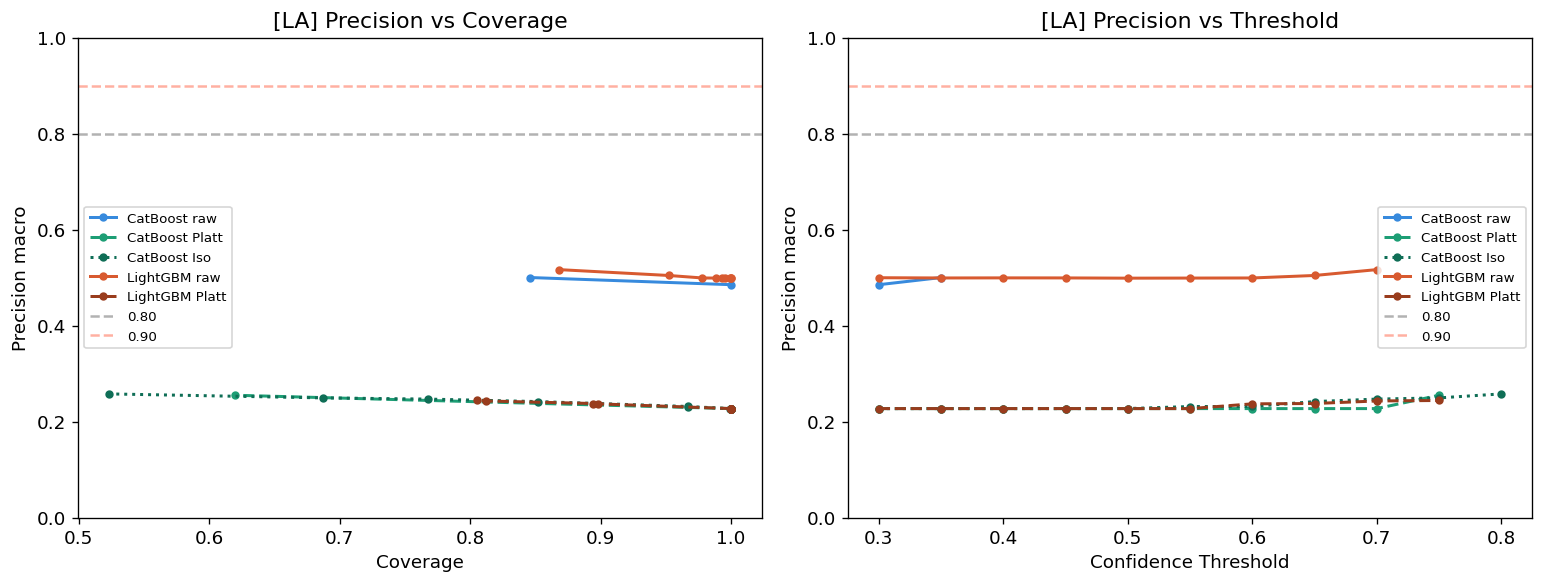

In [14]:
# ============================================================
# CELL 12: Precision-Coverage curve
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors_map = {
    'CatBoost raw':   ('#378ADD', '-'),
    'CatBoost Platt': ('#1D9E75', '--'),
    'CatBoost Iso':   ('#0F6E56', ':'),
    'LightGBM raw':   ('#D85A30', '-'),
    'LightGBM Platt': ('#993C1D', '--'),
}
for label, df_res in sweep_results.items():
    r = df_res.dropna(subset=['precision_macro'])
    if len(r) == 0: continue
    col, ls = colors_map.get(label, ('#888','--'))
    ax1.plot(r['coverage'], r['precision_macro'],
             marker='o', label=label, color=col, ls=ls, lw=1.8, ms=4)
    ax2.plot(r['threshold'], r['precision_macro'],
             marker='o', label=label, color=col, ls=ls, lw=1.8, ms=4)
for ax in [ax1, ax2]:
    ax.axhline(0.8, color='gray',   ls='--', alpha=0.6, label='0.80')
    ax.axhline(0.9, color='tomato', ls='--', alpha=0.5, label='0.90')
    ax.legend(fontsize=8); ax.set_ylim(0,1)
ax1.set_xlabel('Coverage'); ax1.set_ylabel('Precision macro')
ax1.set_title(f'[{CITY}] Precision vs Coverage')
ax2.set_xlabel('Confidence Threshold'); ax2.set_ylabel('Precision macro')
ax2.set_title(f'[{CITY}] Precision vs Threshold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/precision_coverage_{CITY.lower()}.png', dpi=150)
plt.show()

## Section 8 — Class-Specific Threshold

In [15]:
# ============================================================
# CELL 13: Class-specific threshold
# ============================================================
def find_class_thresholds(proba_val, y_val, le, target_precision=0.80):
    thresholds = {}
    for cls_idx, cls_name in enumerate(le.classes_):
        best_t = None
        for t in np.arange(0.30, 0.96, 0.01):
            is_top  = proba_val.argmax(axis=1) == cls_idx
            is_conf = proba_val[:, cls_idx] >= t
            mask    = is_top & is_conf
            if mask.sum() < 10:
                continue
            p = precision_score(
                y_val[mask],
                np.full(mask.sum(), cls_idx),
                labels=[cls_idx], average='micro', zero_division=0
            )
            if p >= target_precision:
                best_t = round(t, 2)
                break
        thresholds[cls_name] = best_t if best_t else 0.95
        print(f'  {cls_name:15s}: threshold = {thresholds[cls_name]:.2f}')
    return thresholds

def apply_class_thresholds(proba, thresholds, le):
    pred = np.full(proba.shape[0], -1, dtype=int)
    for cls_idx, cls_name in enumerate(le.classes_):
        t = thresholds[cls_name]
        is_top  = proba.argmax(axis=1) == cls_idx
        is_conf = proba[:, cls_idx] >= t
        pred[is_top & is_conf] = cls_idx
    return pred

# Use VAL set probabilities to find thresholds
print('Finding class-specific thresholds on VALIDATION set...')
proba_cat_platt_val = apply_calibration(cal_platt_cat, proba_cat_val, 'platt')
class_thresholds    = find_class_thresholds(proba_cat_platt_val, y_val, le, target_precision=0.80)

# Apply to TEST set
print('\nApplying to TEST set...')
pred_cs = apply_class_thresholds(proba_cat_platt, class_thresholds, le)
mask_cs = pred_cs != -1
if mask_cs.sum() > 0:
    pm_cs = precision_score(y_test[mask_cs], pred_cs[mask_cs], average='macro', zero_division=0)
    pw_cs = precision_score(y_test[mask_cs], pred_cs[mask_cs], average='weighted', zero_division=0)
    f1_cs = f1_score(y_test[mask_cs],        pred_cs[mask_cs], average='macro', zero_division=0)
    print(f'Coverage: {mask_cs.mean():.3f}  Precision macro: {pm_cs:.4f}  F1: {f1_cs:.4f}')
    print(safe_report(y_test[mask_cs], pred_cs[mask_cs], le))
else:
    print('No predictions made. All thresholds too high.')

Finding class-specific thresholds on VALIDATION set...
  other          : threshold = 0.95
  property       : threshold = 0.95
  violent        : threshold = 0.95

Applying to TEST set...
No predictions made. All thresholds too high.


## Section 9 — Two-Stage Model

In [16]:
# ============================================================
# CELL 14: Two-stage model
# Stage 1: Is this grid stable (predictable)?
# Stage 2: For stable grids -> predict dominant category
# ============================================================
from catboost import CatBoostClassifier, Pool

DOMINANCE_THRESHOLD = 0.30

# Stage 1 labels: stable if dominance_gap >= threshold
y_s1_train = (grid_train['dominance_gap'].values >= DOMINANCE_THRESHOLD).astype(int)
y_s1_val   = (grid_val['dominance_gap'].values   >= DOMINANCE_THRESHOLD).astype(int)
y_s1_test  = (grid_test['dominance_gap'].values  >= DOMINANCE_THRESHOLD).astype(int)

print(f'Stable grids — Train: {y_s1_train.mean():.1%}  Val: {y_s1_val.mean():.1%}  Test: {y_s1_test.mean():.1%}')

stage1 = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05,
    loss_function='Logloss', eval_metric='F1',
    cat_features=cat_idx, random_seed=42, verbose=50,
)
stage1.fit(
    Pool(prep_cat(X_train), y_s1_train, cat_features=cat_idx),
    eval_set=Pool(prep_cat(X_val), y_s1_val, cat_features=cat_idx),
    early_stopping_rounds=40,
)

s1_pred     = stage1.predict(prep_cat(X_test)).flatten()
stable_mask = s1_pred == 1
print(f'\nStage 1 predicted stable: {stable_mask.sum():,}/{len(stable_mask):,} ({stable_mask.mean():.1%})')

Stable grids — Train: 24.7%  Val: 29.5%  Test: 28.3%
0:	learn: 1.0000000	test: 0.4039059	best: 0.4039059 (0)	total: 55.9ms	remaining: 22.3s
50:	learn: 1.0000000	test: 0.4042553	best: 0.4057066 (15)	total: 2.25s	remaining: 15.4s
Stopped by overfitting detector  (40 iterations wait)

bestTest = 0.4057066429
bestIteration = 15

Shrink model to first 16 iterations.

Stage 1 predicted stable: 999/4,130 (24.2%)


===== Two-Stage Model [LA] =====
Coverage           = 0.242
Precision macro    = 0.2566
Precision weighted = 0.5925
F1 macro           = 0.2900
              precision    recall  f1-score   support

       other       0.00      0.00      0.00       137
    property       0.77      1.00      0.87       769
     violent       0.00      0.00      0.00        93

    accuracy                           0.77       999
   macro avg       0.26      0.33      0.29       999
weighted avg       0.59      0.77      0.67       999



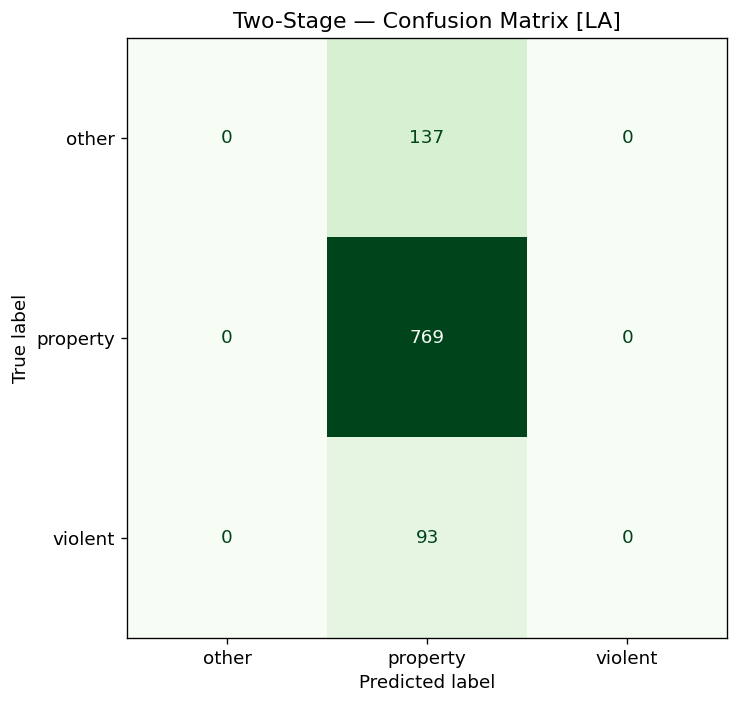

In [17]:
# ============================================================
# CELL 15: Two-stage evaluation
# ============================================================
if stable_mask.sum() > 0:
    y_test_stable = y_test[stable_mask]
    proba_s2      = proba_cat_platt[stable_mask]
    pred_s2       = proba_s2.argmax(axis=1)

    pm_2s = precision_score(y_test_stable, pred_s2, average='macro',    zero_division=0)
    pw_2s = precision_score(y_test_stable, pred_s2, average='weighted', zero_division=0)
    f1_2s = f1_score(y_test_stable,        pred_s2, average='macro',    zero_division=0)

    print(f'===== Two-Stage Model [{CITY}] =====')
    print(f'Coverage           = {stable_mask.mean():.3f}')
    print(f'Precision macro    = {pm_2s:.4f}')
    print(f'Precision weighted = {pw_2s:.4f}')
    print(f'F1 macro           = {f1_2s:.4f}')
    print(safe_report(y_test_stable, pred_s2, le))

    fig, ax = plt.subplots(figsize=(7,6))
    safe_confusion_matrix(y_test_stable, pred_s2, le, ax,
                          f'Two-Stage — Confusion Matrix [{CITY}]', cmap='Greens')
    plt.tight_layout()
    plt.savefig(f'{EDA_DIR}/cm_{CITY.lower()}_two_stage.png', dpi=150)
    plt.show()
else:
    print('No stable grids. Try lowering DOMINANCE_THRESHOLD.')

## Section 10 — Summary Table

In [18]:
# ============================================================
# CELL 16: Summary comparison
# ============================================================
def best_threshold_for_target(sweep_df, target=0.80):
    r = sweep_df.dropna(subset=['precision_macro'])
    if len(r) == 0:
        return None, np.nan, np.nan
    above = r[r['precision_macro'] >= target]
    if len(above) == 0:
        best = r.loc[r['precision_macro'].idxmax()]
        return best['threshold'], best['precision_macro'], best['coverage']
    row = above.iloc[0]
    return row['threshold'], row['precision_macro'], row['coverage']

def get_selective_metrics(proba, y_test, threshold):
    conf = proba.max(axis=1) >= threshold
    if conf.sum() < 5:
        return np.nan, np.nan, 0.0
    yc = y_test[conf]; pc = proba.argmax(axis=1)[conf]
    return (round(precision_score(yc,pc,average='macro',zero_division=0),4),
            round(precision_score(yc,pc,average='weighted',zero_division=0),4),
            round(conf.mean(),3))

rows = []
rows.append({'Method': 'CatBoost (no threshold)', 'Precision Macro': round(pm_cat,4),
             'Precision Weighted': round(pw_cat,4), 'F1 Macro': round(f1_cat,4), 'Coverage': 1.0, 'Threshold': '-'})
rows.append({'Method': 'LightGBM (no threshold)', 'Precision Macro': round(pm_lgb,4),
             'Precision Weighted': round(pw_lgb,4), 'F1 Macro': round(f1_lgb,4), 'Coverage': 1.0, 'Threshold': '-'})

for label, proba in [('CatBoost raw',   proba_cat),
                      ('CatBoost Platt', proba_cat_platt),
                      ('CatBoost Iso',   proba_cat_iso),
                      ('LightGBM Platt', proba_lgb_platt)]:
    if label not in sweep_results: continue
    t, pm, cov = best_threshold_for_target(sweep_results[label], target=0.80)
    if t is None: continue
    _, pw, _ = get_selective_metrics(proba, y_test, t)
    f1t = sweep_results[label][sweep_results[label]['threshold']==t]['f1_macro'].values
    f1v = float(f1t[0]) if len(f1t) > 0 else np.nan
    rows.append({'Method': f'{label} + t={t}', 'Precision Macro': pm,
                 'Precision Weighted': pw, 'F1 Macro': f1v, 'Coverage': cov, 'Threshold': t})

if 'pred_cs' in dir() and mask_cs.sum() > 0:
    rows.append({'Method': 'CatBoost Platt + class-threshold', 'Precision Macro': round(pm_cs,4),
                 'Precision Weighted': round(pw_cs,4), 'F1 Macro': round(f1_cs,4),
                 'Coverage': round(mask_cs.mean(),3), 'Threshold': 'per-class'})

if 'stable_mask' in dir() and stable_mask.sum() > 0:
    rows.append({'Method': f'Two-Stage (dom_gap>{DOMINANCE_THRESHOLD})', 'Precision Macro': round(pm_2s,4),
                 'Precision Weighted': round(pw_2s,4), 'F1 Macro': round(f1_2s,4),
                 'Coverage': round(stable_mask.mean(),3), 'Threshold': f'>{DOMINANCE_THRESHOLD}'})

summary_df = pd.DataFrame(rows)
print(f'\n===== Method Comparison [{CITY}] =====')
print(summary_df.to_string(index=False))
summary_df.to_csv(f'{MODEL_DIR}/method_comparison_{CITY.lower()}.csv', index=False)


===== Method Comparison [LA] =====
                 Method  Precision Macro  Precision Weighted  F1 Macro  Coverage Threshold
CatBoost (no threshold)           0.4853              0.6256    0.4828     1.000         -
LightGBM (no threshold)           0.4998              0.6204    0.4560     1.000         -
  CatBoost raw + t=0.35           0.5002              0.6420    0.4873     0.846      0.35
CatBoost Platt + t=0.75           0.2550              0.5853    0.2890     0.620      0.75
   CatBoost Iso + t=0.8           0.2578              0.5981    0.2907     0.523       0.8
LightGBM Platt + t=0.75           0.2441              0.5363    0.2818     0.805      0.75
Two-Stage (dom_gap>0.3)           0.2566              0.5925    0.2900     0.242      >0.3


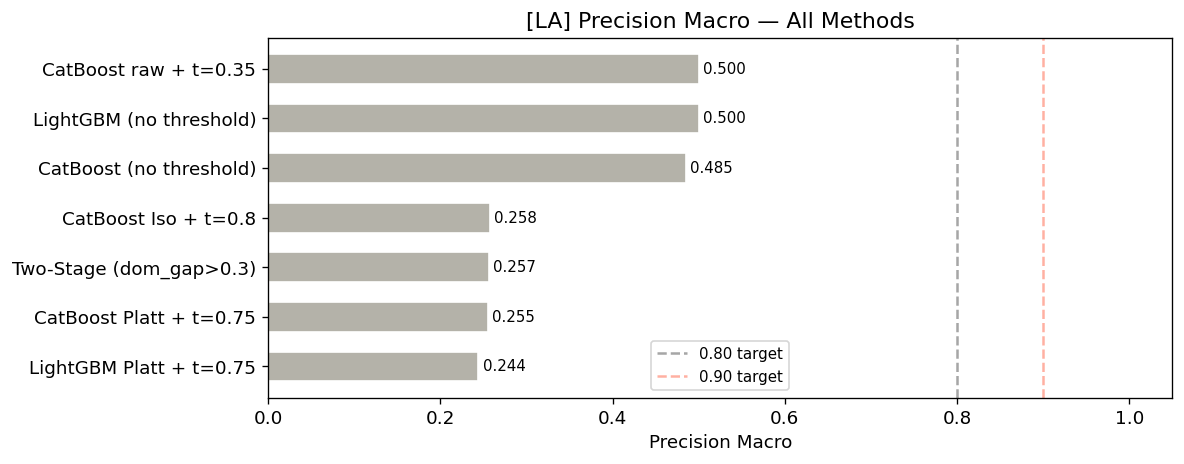

In [19]:
# ============================================================
# CELL 17: Summary bar chart
# ============================================================
plot_df = summary_df.dropna(subset=['Precision Macro']).sort_values('Precision Macro')
fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df)*0.55)))
colors = ['#E24B4A' if v>=0.80 else '#378ADD' if v>=0.60 else '#B4B2A9'
          for v in plot_df['Precision Macro']]
bars = ax.barh(plot_df['Method'], plot_df['Precision Macro'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(0.80, color='gray',   ls='--', alpha=0.7, label='0.80 target')
ax.axvline(0.90, color='tomato', ls='--', alpha=0.5, label='0.90 target')
for bar, val in zip(bars, plot_df['Precision Macro']):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Precision Macro')
ax.set_title(f'[{CITY}] Precision Macro — All Methods')
ax.set_xlim(0, 1.05); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/method_comparison_{CITY.lower()}.png', dpi=150)
plt.show()

## Section 11 — Transfer Learning

Feature Domain Shift: NYC vs Chicago
      feature    jsd
   hist_other 0.7943
hist_property 0.5077
 hist_violent 0.4579
      entropy 0.4238
   top1_ratio 0.3432
dominance_gap 0.2476
    log_count 0.1359


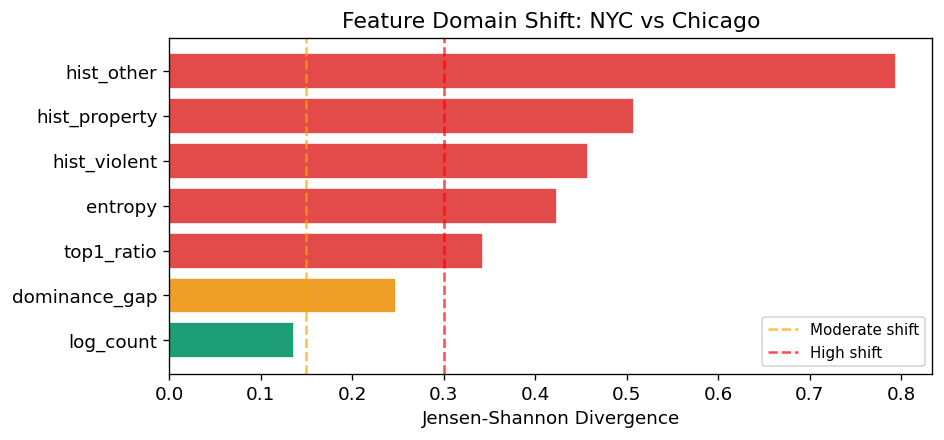

In [20]:
# ============================================================
# CELL 18: Domain shift quantification (JSD)
# ============================================================
def compute_feature_jsd(grid_a, grid_b, feat_cols, bins=20):
    results = []
    for col in feat_cols:
        if col not in grid_a.columns or col not in grid_b.columns:
            continue
        va = grid_a[col].dropna().values
        vb = grid_b[col].dropna().values
        all_v = np.concatenate([va, vb])
        edges = np.linspace(all_v.min(), all_v.max()+1e-9, bins+1)
        ha, _ = np.histogram(va, bins=edges, density=True)
        hb, _ = np.histogram(vb, bins=edges, density=True)
        ha = ha+1e-9; hb = hb+1e-9
        ha /= ha.sum(); hb /= hb.sum()
        results.append({'feature': col, 'jsd': round(float(jensenshannon(ha, hb)),4)})
    return pd.DataFrame(results).sort_values('jsd', ascending=False)

cities_available = list(df['city'].unique())
if len(cities_available) >= 2:
    city_a, city_b = cities_available[0], cities_available[1]
    events_a = df[df['city']==city_a]
    events_b = df[df['city']==city_b]
    # Use full-period grids for JSD comparison
    g_a = build_grid_from_events(events_a)
    g_b = build_grid_from_events(events_b)
    hist_cols = [f'hist_{c}' for c in CATEGORIES] + ['top1_ratio','dominance_gap','entropy','log_count']
    jsd_df = compute_feature_jsd(g_a, g_b, hist_cols)
    print(f'Feature Domain Shift: {city_a} vs {city_b}')
    print(jsd_df.to_string(index=False))
    jsd_df.to_csv(f'{MODEL_DIR}/domain_shift_{city_a.lower()}_{city_b.lower()}.csv', index=False)

    top_n = min(12, len(jsd_df))
    plot_jsd = jsd_df.head(top_n).sort_values('jsd')
    fig, ax = plt.subplots(figsize=(8, top_n*0.4+1))
    colors_jsd = ['#E24B4A' if v>0.3 else '#EF9F27' if v>0.15 else '#1D9E75' for v in plot_jsd['jsd']]
    ax.barh(plot_jsd['feature'], plot_jsd['jsd'], color=colors_jsd, edgecolor='white')
    ax.axvline(0.15, color='orange', ls='--', alpha=0.7, label='Moderate shift')
    ax.axvline(0.30, color='red',    ls='--', alpha=0.7, label='High shift')
    ax.set_xlabel('Jensen-Shannon Divergence')
    ax.set_title(f'Feature Domain Shift: {city_a} vs {city_b}')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{EDA_DIR}/domain_shift_{city_a.lower()}_{city_b.lower()}.png', dpi=150)
    plt.show()
else:
    print('Need at least 2 cities.')

In [21]:
# 貼這行的輸出給我看
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'proba_cat:       {proba_cat.shape}')
print(f'proba_cat_platt: {proba_cat_platt.shape}')
print(f'proba_cat_val:   {proba_cat_val.shape}')

X_train: (4635, 26)  y_train: (4635,)
X_val:   (4173, 26)    y_val:   (4173,)
X_test:  (4130, 26)   y_test:  (4130,)
proba_cat:       (4130, 3)
proba_cat_platt: (4130, 3)
proba_cat_val:   (4173, 3)


In [22]:
print('Chicago grid distribution:')
print(f'Train: \n{grid_train["dominant_category"].value_counts().to_string()}')
print(f'\nTest: \n{grid_test["dominant_category"].value_counts().to_string()}')

Chicago grid distribution:
Train: 
dominant_category
property    3716
violent      497
other        422

Test: 
dominant_category
property    2815
violent      684
other        631


In [23]:
from catboost import CatBoostClassifier
source_model = CatBoostClassifier()
source_model.load_model(f'{MODEL_DIR}/model_nyc_catboost.cbm')
print('NYC source model loaded')

NYC source model loaded


In [24]:
# ============================================================
# CELL 19: Transfer learning experiments
# Source: NYC   Target: Chicago
# Scenarios: zero-shot / fine-tuning 10%/20%/50% / teacher-student
# ============================================================
from catboost import CatBoostClassifier, Pool

SOURCE_CITY = 'NYC'
TARGET_CITY = 'Chicago'

if TARGET_CITY not in df['city'].unique():
    print(f'{TARGET_CITY} not in data yet. Add data and re-run.')
else:
    # Build temporal split for target city
    tgt_events  = df[df['city']==TARGET_CITY].copy()
    tgt_max     = tgt_events['datetime'].max()
    tgt_test_s  = tgt_max - pd.DateOffset(months=6)
    tgt_val_s   = tgt_max - pd.DateOffset(months=12)

    tgt_train_ev = tgt_events[tgt_events['datetime'] <  tgt_val_s]
    tgt_val_ev   = tgt_events[(tgt_events['datetime'] >= tgt_val_s) & (tgt_events['datetime'] < tgt_test_s)]
    tgt_test_ev  = tgt_events[tgt_events['datetime'] >= tgt_test_s]

    tgt_grid_train = build_grid_from_events(tgt_train_ev)
    tgt_grid_val   = build_grid_from_events(tgt_val_ev)
    tgt_grid_test  = build_grid_from_events(tgt_test_ev)

    tgt_grid_train = add_spatial_lag(tgt_grid_train)

    X_tgt_train = make_features(tgt_grid_train, ref_grid=None)
    X_tgt_val   = make_features(tgt_grid_val,   ref_grid=tgt_grid_train)
    X_tgt_test  = make_features(tgt_grid_test,  ref_grid=tgt_grid_train)
    y_tgt_train = le.transform(tgt_grid_train['dominant_category'])
    y_tgt_val   = le.transform(tgt_grid_val['dominant_category'])
    y_tgt_test  = le.transform(tgt_grid_test['dominant_category'])

    print(f'Target {TARGET_CITY}: train={len(X_tgt_train):,} val={len(X_tgt_val):,} test={len(X_tgt_test):,}')

    transfer_results = []

    # --- Target baseline ---
    print(f'\n[Baseline] {TARGET_CITY} trained from scratch...')
    tgt_base = CatBoostClassifier(
        iterations=800, depth=8, learning_rate=0.03,
        loss_function='MultiClass', eval_metric='TotalF1',
        auto_class_weights='Balanced', cat_features=cat_idx, random_seed=42, verbose=0,
    )
    tgt_base.fit(
        Pool(prep_cat(X_tgt_train), y_tgt_train, cat_features=cat_idx),
        eval_set=Pool(prep_cat(X_tgt_val), y_tgt_val, cat_features=cat_idx),
        early_stopping_rounds=80,
    )
    pred_bl = tgt_base.predict(prep_cat(X_tgt_test)).flatten()
    pm_bl = precision_score(y_tgt_test, pred_bl, average='macro', zero_division=0)
    f1_bl = f1_score(y_tgt_test,        pred_bl, average='macro', zero_division=0)
    transfer_results.append({'Scenario': f'{TARGET_CITY} baseline',
                              'Precision Macro': round(pm_bl,4), 'F1 Macro': round(f1_bl,4),
                              'Coverage': 1.0, 'Note': 'no transfer'})
    print(f'  Precision={pm_bl:.4f}  F1={f1_bl:.4f}')

    # --- Zero-shot ---
    print(f'\n[Zero-shot] {SOURCE_CITY} -> {TARGET_CITY}...')
    pred_zs = source_model.predict(prep_cat(X_tgt_test)).flatten()
    pm_zs = precision_score(y_tgt_test, pred_zs, average='macro', zero_division=0)
    f1_zs = f1_score(y_tgt_test,        pred_zs, average='macro', zero_division=0)
    transfer_results.append({'Scenario': f'{SOURCE_CITY}->{TARGET_CITY} zero-shot',
                              'Precision Macro': round(pm_zs,4), 'F1 Macro': round(f1_zs,4),
                              'Coverage': 1.0, 'Note': '0% target data'})
    print(f'  Precision={pm_zs:.4f}  F1={f1_zs:.4f}')

    # --- Fine-tuning ---
    for pct in [0.10, 0.20, 0.50]:
        print(f'\n[Fine-tune {int(pct*100)}%] {SOURCE_CITY} -> {TARGET_CITY}...')
        n_ft   = max(10, int(len(X_tgt_train)*pct))
        idx_ft = np.random.RandomState(42).choice(len(X_tgt_train), n_ft, replace=False)

        # Add source model predictions as extra features (soft transfer)
        src_proba_train = source_model.predict_proba(prep_cat(X_tgt_train.iloc[idx_ft]))
        src_proba_test  = source_model.predict_proba(prep_cat(X_tgt_test))

        src_cols = [f'src_{c}' for c in le.classes_]
        X_ft_aug = pd.concat([
            X_tgt_train.iloc[idx_ft].reset_index(drop=True),
            pd.DataFrame(src_proba_train, columns=src_cols)
        ], axis=1)
        X_tgt_test_ft = pd.concat([
            X_tgt_test.reset_index(drop=True),
            pd.DataFrame(src_proba_test, columns=src_cols)
        ], axis=1)

        ft_model = CatBoostClassifier(
            iterations=400, depth=6, learning_rate=0.05,
            loss_function='MultiClass', eval_metric='TotalF1',
            auto_class_weights='Balanced', cat_features=cat_idx,
            random_seed=42, verbose=0,
        )
        ft_model.fit(Pool(prep_cat(X_ft_aug), y_tgt_train[idx_ft], cat_features=cat_idx))

        pred_ft = ft_model.predict(prep_cat(X_tgt_test_ft)).flatten()
        pm_ft = precision_score(y_tgt_test, pred_ft, average='macro', zero_division=0)
        f1_ft = f1_score(y_tgt_test,        pred_ft, average='macro', zero_division=0)
        transfer_results.append({
            'Scenario': f'Fine-tune {int(pct*100)}% (src features)',
            'Precision Macro': round(pm_ft,4), 'F1 Macro': round(f1_ft,4),
            'Coverage': 1.0, 'Note': f'{int(pct*100)}% target + source proba'
        })
        print(f'  Precision={pm_ft:.4f}  F1={f1_ft:.4f}')
    # --- Teacher-Student ---
    print(f'\n[Teacher-Student] {SOURCE_CITY} -> {TARGET_CITY}...')
    TEMPERATURE = 3.0
    teacher_raw = source_model.predict_proba(prep_cat(X_tgt_train))
    logits      = np.log(teacher_raw+1e-9) / TEMPERATURE
    soft_labels = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    soft_df     = pd.DataFrame(soft_labels, columns=[f'teacher_{c}' for c in le.classes_])
    X_stu_aug   = pd.concat([X_tgt_train.reset_index(drop=True), soft_df], axis=1)

    teacher_test_raw = source_model.predict_proba(prep_cat(X_tgt_test))
    logits_te        = np.log(teacher_test_raw+1e-9) / TEMPERATURE
    soft_te          = np.exp(logits_te) / np.exp(logits_te).sum(axis=1, keepdims=True)
    soft_te_df       = pd.DataFrame(soft_te, columns=[f'teacher_{c}' for c in le.classes_])
    X_tgt_test_aug   = pd.concat([X_tgt_test.reset_index(drop=True), soft_te_df], axis=1)

    # Teacher-Student val set
    teacher_val_raw = source_model.predict_proba(prep_cat(X_tgt_val))
    logits_va       = np.log(teacher_val_raw+1e-9) / TEMPERATURE
    soft_va         = np.exp(logits_va) / np.exp(logits_va).sum(axis=1, keepdims=True)
    soft_va_df      = pd.DataFrame(soft_va, columns=[f'teacher_{c}' for c in le.classes_])
    X_tgt_val_aug   = pd.concat([X_tgt_val.reset_index(drop=True), soft_va_df], axis=1)

    student = CatBoostClassifier(
        iterations=600, depth=8, learning_rate=0.03,
        loss_function='MultiClass', eval_metric='TotalF1',
        auto_class_weights='Balanced', cat_features=cat_idx, random_seed=42, verbose=0,
    )
    student.fit(
        Pool(prep_cat(X_stu_aug), y_tgt_train, cat_features=cat_idx),
        eval_set=Pool(prep_cat(X_tgt_val_aug), y_tgt_val, cat_features=cat_idx),
        early_stopping_rounds=60,
    )
    pred_ts = student.predict(prep_cat(X_tgt_test_aug)).flatten()
    pm_ts = precision_score(y_tgt_test, pred_ts, average='macro', zero_division=0)
    f1_ts = f1_score(y_tgt_test,        pred_ts, average='macro', zero_division=0)
    transfer_results.append({'Scenario': f'Teacher-Student (T={TEMPERATURE})',
                              'Precision Macro': round(pm_ts,4), 'F1 Macro': round(f1_ts,4),
                              'Coverage': 1.0, 'Note': 'soft labels'})
    print(f'  Precision={pm_ts:.4f}  F1={f1_ts:.4f}')

    tr_df = pd.DataFrame(transfer_results)
    print(f'\n===== Transfer Results: {SOURCE_CITY} -> {TARGET_CITY} =====')
    print(tr_df.to_string(index=False))
    tr_df.to_csv(f'{MODEL_DIR}/transfer_{SOURCE_CITY.lower()}_{TARGET_CITY.lower()}.csv', index=False)

Target Chicago: train=2,878 val=2,436 test=2,447

[Baseline] Chicago trained from scratch...
  Precision=0.4387  F1=0.4147

[Zero-shot] NYC -> Chicago...
  Precision=0.6136  F1=0.2115

[Fine-tune 10%] NYC -> Chicago...
  Precision=0.4372  F1=0.4120

[Fine-tune 20%] NYC -> Chicago...
  Precision=0.4378  F1=0.4140

[Fine-tune 50%] NYC -> Chicago...
  Precision=0.4386  F1=0.4126

[Teacher-Student] NYC -> Chicago...
  Precision=0.4224  F1=0.4242

===== Transfer Results: NYC -> Chicago =====
                    Scenario  Precision Macro  F1 Macro  Coverage                      Note
            Chicago baseline           0.4387    0.4147       1.0               no transfer
      NYC->Chicago zero-shot           0.6136    0.2115       1.0            0% target data
Fine-tune 10% (src features)           0.4372    0.4120       1.0 10% target + source proba
Fine-tune 20% (src features)           0.4378    0.4140       1.0 20% target + source proba
Fine-tune 50% (src features)           0.4386   

In [25]:
print('Chicago dominant category distribution:')
print(tgt_grid_train['dominant_category'].value_counts().to_string())
print('\nNYC le.classes_:', le.classes_)

Chicago dominant category distribution:
dominant_category
property    2417
violent      452
other          9

NYC le.classes_: ['other' 'property' 'violent']


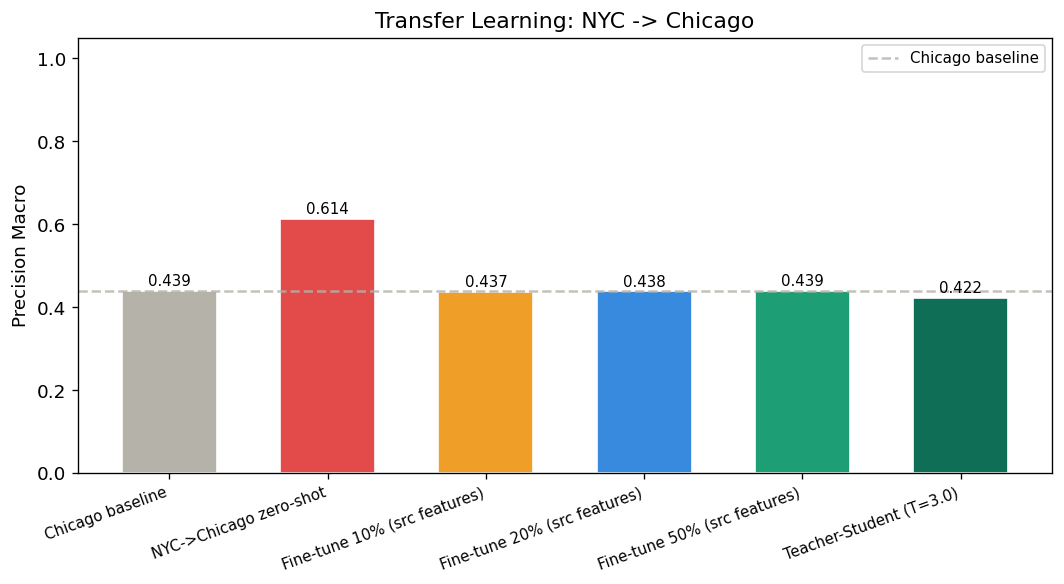

In [26]:
# ============================================================
# CELL 20: Transfer results chart
# ============================================================
if 'tr_df' in dir():
    fig, ax = plt.subplots(figsize=(9,5))
    palette = ['#B4B2A9','#E24B4A','#EF9F27','#378ADD','#1D9E75','#0F6E56']
    bars = ax.bar(range(len(tr_df)), tr_df['Precision Macro'],
                  color=palette[:len(tr_df)], edgecolor='white', width=0.6)
    ax.axhline(pm_bl, color='#B4B2A9', ls='--', alpha=0.8, label=f'{TARGET_CITY} baseline')
    for bar, val in zip(bars, tr_df['Precision Macro']):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(len(tr_df)))
    ax.set_xticklabels(tr_df['Scenario'], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Precision Macro')
    ax.set_title(f'Transfer Learning: {SOURCE_CITY} -> {TARGET_CITY}')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{EDA_DIR}/transfer_{SOURCE_CITY.lower()}_{TARGET_CITY.lower()}.png', dpi=150)
    plt.show()

## Section 12 — Feature Importance & Save

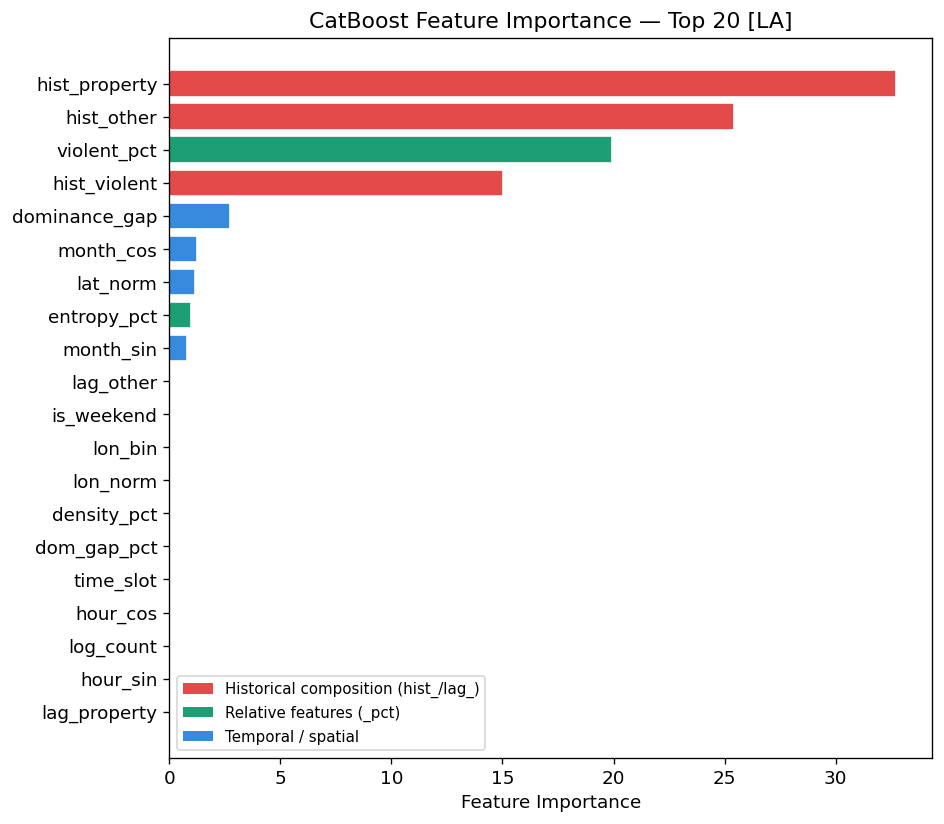

In [27]:
# ============================================================
# CELL 21: Feature importance
# ============================================================
fi = pd.DataFrame({'feature': X_train.columns,
                    'importance': model_cat.get_feature_importance()})
fi = fi.sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8,7))
colors_fi = ['#E24B4A' if ('hist_' in f or 'lag_' in f) else
              '#1D9E75' if 'pct' in f else '#378ADD'
              for f in fi['feature']]
ax.barh(fi['feature'], fi['importance'], color=colors_fi, edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title(f'CatBoost Feature Importance — Top 20 [{CITY}]')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#E24B4A', label='Historical composition (hist_/lag_)'),
    Patch(facecolor='#1D9E75', label='Relative features (_pct)'),
    Patch(facecolor='#378ADD', label='Temporal / spatial'),
], fontsize=9)
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/feature_importance_{CITY.lower()}.png', dpi=150)
plt.show()

In [28]:
# ============================================================
# CELL 22: Save models + grid risk scores for Folium map
# ============================================================
model_cat.save_model(f'{MODEL_DIR}/model_{CITY.lower()}_catboost.cbm')
joblib.dump(model_lgb,     f'{MODEL_DIR}/model_{CITY.lower()}_lgb.pkl')
joblib.dump(cal_platt_cat, f'{MODEL_DIR}/cal_platt_{CITY.lower()}.pkl')
joblib.dump(le,            f'{MODEL_DIR}/label_encoder_{CITY.lower()}.pkl')

# Predict on all test grids
proba_all_raw = model_cat.predict_proba(prep_cat(X_test))
proba_all_cal = apply_calibration(cal_platt_cat, proba_all_raw, 'platt')
pred_all      = proba_all_cal.argmax(axis=1)
violent_idx   = list(le.classes_).index('violent')

risk_df = grid_test[['lat_bin','lon_bin','time_slot','total_count',
                      'dominant_category','dominance_gap','entropy']].copy()
risk_df['predicted_category']   = le.inverse_transform(pred_all)
risk_df['confidence_calibrated']= proba_all_cal.max(axis=1).round(4)
risk_df['correct']              = (risk_df['predicted_category'] == risk_df['dominant_category'])
for i, cat in enumerate(le.classes_):
    risk_df[f'proba_{cat}'] = proba_all_cal[:,i].round(4)
risk_df['risk_score'] = (proba_all_cal[:,violent_idx] * 100).round(1)
risk_df['city']       = CITY
risk_df['confidence_tier'] = risk_df['confidence_calibrated'].apply(
    lambda c: 'high' if c>=0.80 else 'medium' if c>=0.55 else 'uncertain'
)

out_path = f'{MODEL_DIR}/grid_risk_{CITY.lower()}.csv'
risk_df.to_csv(out_path, index=False)
print(f'Grid risk scores: {out_path}  ({len(risk_df):,} grids)')
print(f'Accuracy: {risk_df["correct"].mean():.4f}')
print(f'Confidence tier breakdown:')
print(risk_df['confidence_tier'].value_counts().to_string())
print(f'\nTo run Chicago: change CITY = "Chicago" in Cell 3 and re-run from Cell 3.')

Grid risk scores: ../outputs/models/grid_risk_la.csv  (4,130 grids)
Accuracy: 0.6816
Confidence tier breakdown:
confidence_tier
medium    4130

To run Chicago: change CITY = "Chicago" in Cell 3 and re-run from Cell 3.


In [29]:
print('Test grid dominant category distribution:')
print(grid_test['dominant_category'].value_counts().to_string())
print('\nVal grid dominant category distribution:')
print(grid_val['dominant_category'].value_counts().to_string())
print('\nTrain grid dominant category distribution:')
print(grid_train['dominant_category'].value_counts().to_string())

Test grid dominant category distribution:
dominant_category
property    2815
violent      684
other        631

Val grid dominant category distribution:
dominant_category
property    3122
other        567
violent      484

Train grid dominant category distribution:
dominant_category
property    3716
violent      497
other        422


In [30]:
# ============================================================
# CELL A: Clean evaluation (exclude tiny-support classes)
# Paste this after Cell 17 (summary table)
# ============================================================

def clean_eval(model, X_test, y_test, le, name, use_cat=False,
               min_support=30):
    """
    Evaluate only on classes with enough test samples.
    Excludes classes with support < min_support to avoid
    misleading macro averages from 14-sample classes.
    """
    Xt     = prep_cat(X_test) if use_cat else X_test
    y_pred = model.predict(Xt)
    if hasattr(y_pred, 'flatten'):
        y_pred = y_pred.flatten()
    proba  = model.predict_proba(Xt)

    # Find classes with enough support
    from collections import Counter
    support = Counter(y_test)
    valid_classes = [cls for cls in range(len(le.classes_))
                     if support[cls] >= min_support]
    valid_names   = [le.classes_[i] for i in valid_classes]

    mask = np.isin(y_test, valid_classes)
    y_t  = y_test[mask]
    y_p  = np.array(y_pred)[mask]

    pm = precision_score(y_t, y_p, labels=valid_classes,
                         average='macro', zero_division=0)
    pw = precision_score(y_t, y_p, labels=valid_classes,
                         average='weighted', zero_division=0)
    f1 = f1_score(y_t,     y_p, labels=valid_classes,
                  average='macro', zero_division=0)

    print(f'\n===== {name} [{CITY}] — Meaningful Classes Only =====')
    print(f'Excluded classes with support < {min_support}')
    print(f'Evaluated on: {valid_names}')
    print(f'Precision macro    = {pm:.4f}')
    print(f'Precision weighted = {pw:.4f}')
    print(f'F1 macro           = {f1:.4f}')
    print(classification_report(
        y_t, y_p,
        labels=valid_classes,
        target_names=valid_names,
        zero_division=0
    ))
    return pm, pw, f1

# Run clean evaluation
print('=== Clean Evaluation (exclude tiny-support classes) ===')
clean_eval(model_cat, X_test, y_test, le, 'CatBoost', use_cat=True)
clean_eval(model_lgb, X_test, y_test, le, 'LightGBM')

# Also show best threshold version
best_proba = proba_lgb_platt  # change to whichever is best
BEST_THRESHOLD = 0.45         # change to your best threshold
conf = best_proba.max(axis=1) >= BEST_THRESHOLD
if conf.sum() > 0:
    y_conf = y_test[conf]
    p_conf = best_proba.argmax(axis=1)[conf]
    from collections import Counter
    support = Counter(y_conf)
    valid_classes = [cls for cls in range(len(le.classes_))
                     if support[cls] >= 30]
    valid_names   = [le.classes_[i] for i in valid_classes]
    mask = np.isin(y_conf, valid_classes)
    pm = precision_score(y_conf[mask], p_conf[mask],
                         labels=valid_classes, average='macro', zero_division=0)
    print(f'\nLightGBM Platt + t={BEST_THRESHOLD} (meaningful classes):')
    print(f'Precision macro = {pm:.4f}  Coverage = {conf.mean():.3f}')

=== Clean Evaluation (exclude tiny-support classes) ===

===== CatBoost [LA] — Meaningful Classes Only =====
Excluded classes with support < 30
Evaluated on: ['other', 'property', 'violent']
Precision macro    = 0.4853
Precision weighted = 0.6256
F1 macro           = 0.4828
              precision    recall  f1-score   support

       other       0.26      0.24      0.25       631
    property       0.75      0.77      0.76      2815
     violent       0.45      0.43      0.44       684

    accuracy                           0.63      4130
   macro avg       0.49      0.48      0.48      4130
weighted avg       0.63      0.63      0.63      4130


===== LightGBM [LA] — Meaningful Classes Only =====
Excluded classes with support < 30
Evaluated on: ['other', 'property', 'violent']
Precision macro    = 0.4998
Precision weighted = 0.6204
F1 macro           = 0.4560
              precision    recall  f1-score   support

       other       0.29      0.15      0.20       631
    property    

In [31]:
# ============================================================
# CELL B: Save both cities' models and grid risk scores
# Run this after Cell 22 for EACH city
# ============================================================

import joblib
from catboost import CatBoostClassifier

def save_city_outputs(CITY, model_cat, model_lgb,
                      cal_platt_cat, le,
                      X_test, grid_test,
                      proba_cat, cal_iso_cat=None):
    """Save model + grid risk CSV for one city."""

    # Save models
    model_cat.save_model(f'{MODEL_DIR}/model_{CITY.lower()}_catboost.cbm')
    joblib.dump(model_lgb,     f'{MODEL_DIR}/model_{CITY.lower()}_lgb.pkl')
    joblib.dump(cal_platt_cat, f'{MODEL_DIR}/cal_platt_{CITY.lower()}.pkl')
    joblib.dump(le,            f'{MODEL_DIR}/label_encoder_{CITY.lower()}.pkl')
    if cal_iso_cat:
        joblib.dump(cal_iso_cat, f'{MODEL_DIR}/cal_iso_{CITY.lower()}.pkl')

    # Calibrated probabilities
    proba_cal = apply_calibration(cal_platt_cat, proba_cat, 'platt')
    pred_all  = proba_cal.argmax(axis=1)

    violent_idx = list(le.classes_).index('violent') if 'violent' in le.classes_ else 0

    risk_df = grid_test[['lat_bin','lon_bin','time_slot',
                          'total_count','dominant_category',
                          'dominance_gap','entropy']].copy()
    risk_df = risk_df.reset_index(drop=True)

    risk_df['predicted_category']    = le.inverse_transform(pred_all)
    risk_df['confidence_calibrated'] = proba_cal.max(axis=1).round(4)
    risk_df['correct'] = (
        risk_df['predicted_category'] == risk_df['dominant_category']
    )
    for i, cat in enumerate(le.classes_):
        risk_df[f'proba_{cat}'] = proba_cal[:, i].round(4)

    risk_df['risk_score'] = (proba_cal[:, violent_idx] * 100).round(1)
    risk_df['city']       = CITY

    def conf_tier(c):
        if c >= 0.80:   return 'high'
        elif c >= 0.55: return 'medium'
        else:           return 'uncertain'

    risk_df['confidence_tier'] = risk_df['confidence_calibrated'].apply(conf_tier)

    out = f'{MODEL_DIR}/grid_risk_{CITY.lower()}.csv'
    risk_df.to_csv(out, index=False)
    print(f'[{CITY}] Saved: {out}  ({len(risk_df):,} grids)')
    print(f'  Accuracy:    {risk_df["correct"].mean():.4f}')
    print(f'  Conf tiers:  {risk_df["confidence_tier"].value_counts().to_dict()}')
    return risk_df

# Call for current city (change CITY variable as needed)
risk_df_current = save_city_outputs(
    CITY, model_cat, model_lgb,
    cal_platt_cat, le,
    X_test, grid_test,
    proba_cat, cal_iso_cat
)

[LA] Saved: ../outputs/models/grid_risk_la.csv  (4,130 grids)
  Accuracy:    0.6816
  Conf tiers:  {'medium': 4130}


In [32]:
# ============================================================
# CELL C: Folium interactive map
# Run after saving BOTH cities' grid_risk CSVs
# ============================================================

import folium
from folium.plugins import HeatMap
import os

MAP_DIR = '../outputs/maps'
os.makedirs(MAP_DIR, exist_ok=True)

# Color scheme
TIER_COLORS = {
    'high':      '#E24B4A',   # red
    'medium':    '#EF9F27',   # orange
    'uncertain': '#888780',   # gray
}
CAT_COLORS = {
    'violent':      '#E24B4A',
    'property':     '#378ADD',
    'other':        '#1D9E75',
    'public_order': '#EF9F27',
    'drug':         '#7F77DD',
}

def build_city_map(city_name, risk_csv_path, center, zoom=11):
    """
    Build Folium map for one city.
    Layers:
      - Predicted Category (colored by crime type)
      - Risk Score Heatmap (violent crime probability)
    """
    risk_df = pd.read_csv(risk_csv_path)
    print(f'[{city_name}] {len(risk_df):,} grids loaded')

    m = folium.Map(
        location=center,
        zoom_start=zoom,
        tiles='CartoDB positron',
    )

    # ---- Layer 1: Predicted category (rectangles) ----
    time_slots = {
        0: 'Night (00-06h)',
        1: 'Morning (06-12h)',
        2: 'Afternoon (12-18h)',
        3: 'Evening (18-24h)',
    }
    for slot_id, slot_name in time_slots.items():
        fg = folium.FeatureGroup(
            name=f'Predicted Category — {slot_name}',
            show=(slot_id == 2)   # show afternoon by default
        )
        slot_df = risk_df[risk_df['time_slot'] == slot_id]

        for _, row in slot_df.iterrows():
            cat   = row['predicted_category']
            tier  = row['confidence_tier']
            score = row['risk_score']
            conf  = row['confidence_calibrated']
            color = CAT_COLORS.get(cat, '#888780')

            # Opacity based on confidence tier
            opacity = 0.65 if tier == 'high' else \
                      0.40 if tier == 'medium' else 0.20

            # Tooltip content
            proba_lines = ''.join([
                f'<br>{c}: {row[f"proba_{c}"]:.3f}'
                for c in ['violent','property','other']
                if f'proba_{c}' in row.index
            ])
            tooltip_html = (
                f'<b>Predicted: {cat}</b><br>'
                f'Actual: {row["dominant_category"]}<br>'
                f'Confidence: {conf:.3f} ({tier})<br>'
                f'Risk score: {score:.1f}/100<br>'
                f'Records: {int(row["total_count"])}'
                f'{proba_lines}'
            )

            folium.Rectangle(
                bounds=[
                    [row['lat_bin']-0.005, row['lon_bin']-0.005],
                    [row['lat_bin']+0.005, row['lon_bin']+0.005],
                ],
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=opacity,
                weight=0,
                tooltip=folium.Tooltip(tooltip_html),
            ).add_to(fg)

        fg.add_to(m)

    # ---- Layer 2: Violent crime heatmap ----
    for slot_id, slot_name in time_slots.items():
        slot_df = risk_df[risk_df['time_slot'] == slot_id]
        heat_data = [
            [row['lat_bin'], row['lon_bin'], row['risk_score']/100]
            for _, row in slot_df.iterrows()
            if row['risk_score'] > 10
        ]
        if heat_data:
            fg_heat = folium.FeatureGroup(
                name=f'Violent Risk Heatmap — {slot_name}',
                show=False
            )
            HeatMap(
                heat_data,
                radius=14, blur=18, min_opacity=0.2,
                gradient={'0.3': '#1D9E75', '0.6': '#EF9F27', '1.0': '#E24B4A'},
            ).add_to(fg_heat)
            fg_heat.add_to(m)

    # Layer control
    folium.LayerControl(collapsed=False, position='topright').add_to(m)

    # Legend
    legend_html = """
    <div style="
        position: absolute; bottom: 40px; left: 40px; z-index: 1000;
        background: white; padding: 14px 18px;
        border-radius: 10px; border: 1px solid #ddd;
        font-family: sans-serif; font-size: 13px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.15);
    ">
        <b style="font-size:14px">Crime Category</b><br>
        <span style="color:#E24B4A">&#9632;</span> Violent<br>
        <span style="color:#378ADD">&#9632;</span> Property<br>
        <span style="color:#1D9E75">&#9632;</span> Other<br>
        <br>
        <b style="font-size:14px">Confidence</b><br>
        High opacity = high confidence<br>
        Low opacity = uncertain
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    out_path = f'{MAP_DIR}/map_{city_name.lower()}.html'
    m.save(out_path)
    print(f'[{city_name}] Map saved: {out_path}')
    print(f'  Open in browser to view the interactive map.')
    return out_path


# ---- City configs ----
CITY_CONFIGS = {
    'NYC':     {'center': [40.730, -73.935], 'zoom': 11},
    'Chicago': {'center': [41.850, -87.680], 'zoom': 11},
}

# ---- Build maps for all available cities ----
for city_name, config in CITY_CONFIGS.items():
    risk_path = f'{MODEL_DIR}/grid_risk_{city_name.lower()}.csv'
    if os.path.exists(risk_path):
        build_city_map(
            city_name,
            risk_path,
            center=config['center'],
            zoom=config['zoom'],
        )
    else:
        print(f'[{city_name}] grid_risk CSV not found: {risk_path}')
        print(f'  Run save_city_outputs() for {city_name} first.')

print('\nDone! Open outputs/maps/map_nyc.html in your browser.')


[NYC] 3,430 grids loaded
[NYC] Map saved: ../outputs/maps/map_nyc.html
  Open in browser to view the interactive map.
[Chicago] 2,641 grids loaded
[Chicago] Map saved: ../outputs/maps/map_chicago.html
  Open in browser to view the interactive map.

Done! Open outputs/maps/map_nyc.html in your browser.


*Feature Ablation Study*

Spatial only                         n= 4  P=0.4199  F1=0.4171
Spatial + Temporal                   n=13  P=0.4357  F1=0.4241
Spatial + Temporal + Relative        n=17  P=0.4810  F1=0.4332
hist_* only                          n= 3  P=0.4911  F1=0.4784
lag_* only                           n= 3  P=0.4085  F1=0.4101
hist_* + lag_*                       n= 6  P=0.4913  F1=0.4771
Stability features                   n= 3  P=0.4006  F1=0.4004
All features (full model)            n=26  P=0.4853  F1=0.4828

===== Feature Ablation Study [LA] =====
                Feature Group  N Features  Precision Macro  Precision Weighted  F1 Macro
               hist_* + lag_*           6           0.4913              0.6247    0.4771
                  hist_* only           3           0.4911              0.6255    0.4784
    All features (full model)          26           0.4853              0.6256    0.4828
Spatial + Temporal + Relative          17           0.4810              0.6452    0.4332
          

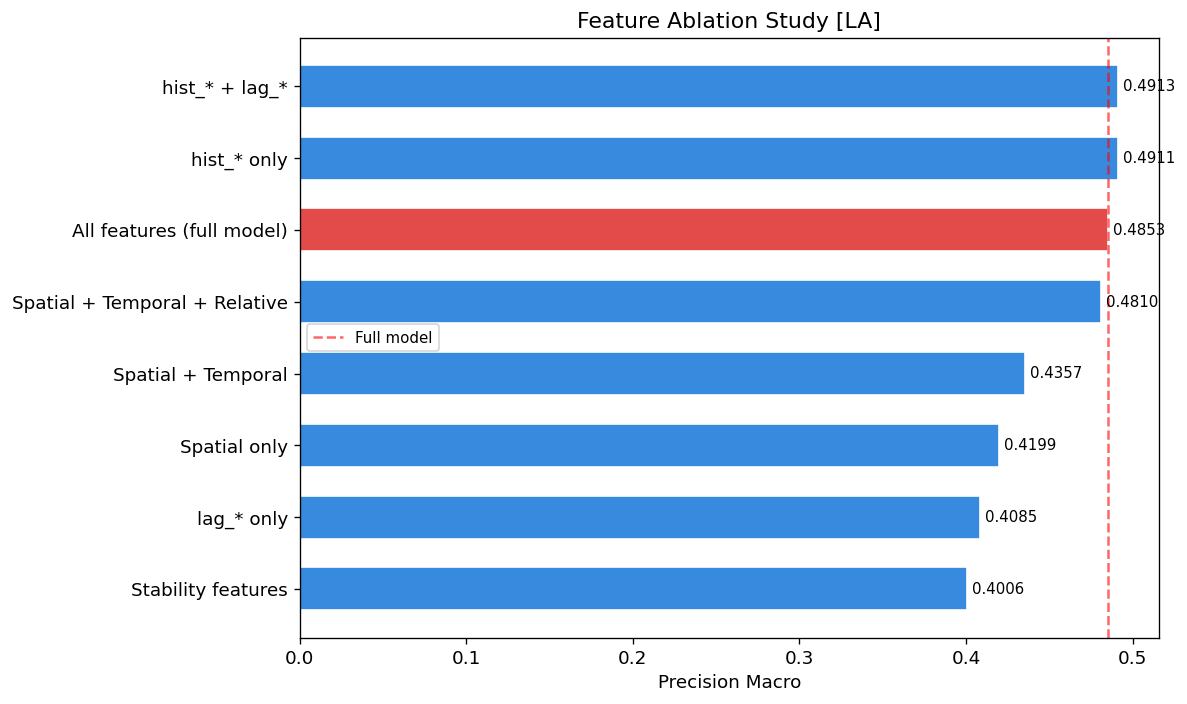

Saved ablation_la.png


In [33]:
# ============================================================
# CELL: Feature Ablation Study
# Train separate models with different feature groups
# to understand which features drive performance
# ============================================================
from catboost import CatBoostClassifier, Pool

ABLATION_GROUPS = {
    'Spatial only': [
        'lat_bin','lon_bin','lat_norm','lon_norm'
    ],
    'Spatial + Temporal': [
        'lat_bin','lon_bin','lat_norm','lon_norm',
        'time_slot','is_weekend','log_count',
        'hour_sin','hour_cos','month_sin','month_cos',
        'weekday_sin','weekday_cos'
    ],
    'Spatial + Temporal + Relative': [
        'lat_bin','lon_bin','lat_norm','lon_norm',
        'density_pct','violent_pct','entropy_pct','dom_gap_pct',
        'time_slot','is_weekend','log_count',
        'hour_sin','hour_cos','month_sin','month_cos',
        'weekday_sin','weekday_cos'
    ],
    'hist_* only': [f'hist_{c}' for c in CATEGORIES],
    'lag_* only':  [f'lag_{c}'  for c in CATEGORIES],
    'hist_* + lag_*': (
        [f'hist_{c}' for c in CATEGORIES] +
        [f'lag_{c}'  for c in CATEGORIES]
    ),
    'Stability features': [
        'top1_ratio','dominance_gap','entropy'
    ],
    'All features (full model)': FEATURE_COLS,
}

ablation_results = []

for group_name, feat_cols in ABLATION_GROUPS.items():
    # Filter to only columns that exist in X_train
    available = [c for c in feat_cols if c in X_train.columns]
    if len(available) == 0:
        print(f'Skipping {group_name}: no valid features')
        continue

    X_tr = X_train[available]
    X_va = X_val[available]
    X_te = X_test[available]

    # Cat features that exist in this subset
    cat_idx_sub = [available.index(c) for c in CAT_COLS
                   if c in available]

    def prep_sub(Xdf):
        Xc = Xdf.copy()
        for c in CAT_COLS:
            if c in Xc.columns:
                Xc[c] = Xc[c].astype(str)
        return Xc

    model_abl = CatBoostClassifier(
        iterations=400, depth=7, learning_rate=0.05,
        loss_function='MultiClass', eval_metric='TotalF1',
        auto_class_weights='Balanced',
        cat_features=cat_idx_sub,
        random_seed=42, verbose=0,
    )
    model_abl.fit(
        Pool(prep_sub(X_tr), y_train, cat_features=cat_idx_sub),
        eval_set=Pool(prep_sub(X_va), y_val, cat_features=cat_idx_sub),
        early_stopping_rounds=40,
    )

    y_pred_abl = model_abl.predict(prep_sub(X_te)).flatten()
    pm = precision_score(y_test, y_pred_abl, average='macro',    zero_division=0)
    pw = precision_score(y_test, y_pred_abl, average='weighted', zero_division=0)
    f1 = f1_score(y_test,        y_pred_abl, average='macro',    zero_division=0)

    ablation_results.append({
        'Feature Group':    group_name,
        'N Features':       len(available),
        'Precision Macro':  round(pm, 4),
        'Precision Weighted': round(pw, 4),
        'F1 Macro':         round(f1, 4),
    })
    print(f'{group_name:35s}  n={len(available):2d}  P={pm:.4f}  F1={f1:.4f}')

abl_df = pd.DataFrame(ablation_results).sort_values('Precision Macro', ascending=False)
print(f'\n===== Feature Ablation Study [{CITY}] =====')
print(abl_df.to_string(index=False))
abl_df.to_csv(f'{MODEL_DIR}/ablation_{CITY.lower()}.csv', index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
abl_plot = abl_df.sort_values('Precision Macro')
colors_abl = ['#E24B4A' if 'All' in g else '#378ADD'
               for g in abl_plot['Feature Group']]
bars = ax.barh(abl_plot['Feature Group'], abl_plot['Precision Macro'],
               color=colors_abl, edgecolor='white', height=0.6)
for bar, val in zip(bars, abl_plot['Precision Macro']):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.axvline(abl_df[abl_df['Feature Group']=='All features (full model)']
           ['Precision Macro'].values[0],
           color='red', ls='--', alpha=0.6, label='Full model')
ax.set_xlabel('Precision Macro')
ax.set_title(f'Feature Ablation Study [{CITY}]')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/ablation_{CITY.lower()}.png', dpi=150)
plt.show()
print(f'Saved ablation_{CITY.lower()}.png')